In [1]:
!pip install mediapipe

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.6/35.6 MB 51.7 MB/s eta 0:00:00


# Import Required Libraries
Import the necessary libraries, including Mediapipe, dlib, PyTorch, and other relevant libraries.

In [2]:
# Import Required Libraries
import os
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from PIL import Image
import matplotlib.pyplot as plt
import mediapipe as mp
import dlib
import time
import numpy as np
import cv2

# Check if GPU is available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


# Fetch Training Images
Fetch the training images from the 'sample_images' folder.

Mounted at /content/drive
Number of training images fetched: 202599


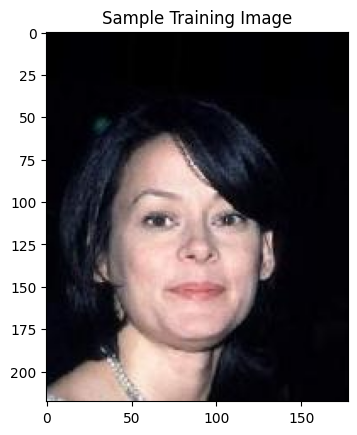

In [3]:
from google.colab import drive
import zipfile

# Mount Google Drive
drive.mount('/content/drive')

# Define the path to the zip file and the extraction folder
zip_file_path = '/content/drive/My Drive/Sample_images.zip'
extraction_folder = '/content/sample_images'

# Unzip the file
with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extraction_folder)

# Fetch all image file paths from the extracted folder and subdirectories
image_files = []
for root, dirs, files in os.walk(extraction_folder):
    for file in files:
        if file.endswith(('jpg', 'jpeg', 'png')):
            image_files.append(os.path.join(root, file))

# Load images into a list
training_images = [Image.open(image_file) for image_file in image_files]

# Display the number of images fetched
print(f"Number of training images fetched: {len(training_images)}")

# Display the first image as a sample
if training_images:
    plt.imshow(training_images[0])
    plt.title('Sample Training Image')
    plt.show()

# Begin Training the Face Generation Model
Start training the face generation model and monitor initial performance metrics.

In [ ]:
import torch
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torchvision.utils import save_image
import os
import numpy as np
from tqdm import tqdm

import torch.nn as nn
import torch.optim as optim

import json
from pathlib import Path

# Function to save checkpoint
def save_checkpoint(generator, discriminator, optimizer_G, optimizer_D, epoch, batch_idx, losses, checkpoint_dir='checkpoints'):
    """Save training checkpoint"""
    Path(checkpoint_dir).mkdir(exist_ok=True)
    
    checkpoint = {
        'epoch': epoch,
        'batch_idx': batch_idx,
        'generator_state': generator.state_dict(),
        'discriminator_state': discriminator.state_dict(),
        'optimizer_G_state': optimizer_G.state_dict(),
        'optimizer_D_state': optimizer_D.state_dict(),
        'losses': losses
    }
    
    checkpoint_path = f"{checkpoint_dir}/checkpoint_epoch{epoch}_batch{batch_idx}.pt"
    torch.save(checkpoint, checkpoint_path)
    
    # Save latest checkpoint reference
    with open(f"{checkpoint_dir}/latest.json", 'w') as f:
        json.dump({'latest_checkpoint': checkpoint_path}, f)
    
    print(f"Saved checkpoint: {checkpoint_path}")

# Function to load checkpoint
def load_checkpoint(generator, discriminator, optimizer_G, optimizer_D, checkpoint_dir='checkpoints'):
    """Load latest training checkpoint if it exists"""
    latest_path = Path(f"{checkpoint_dir}/latest.json")
    
    if not latest_path.exists():
        print("No checkpoint found, starting from beginning")
        return 0, 0, []
    
    with open(latest_path) as f:
        latest = json.load(f)
    
    checkpoint = torch.load(latest['latest_checkpoint'])
    
    generator.load_state_dict(checkpoint['generator_state'])
    discriminator.load_state_dict(checkpoint['discriminator_state'])
    optimizer_G.load_state_dict(checkpoint['optimizer_G_state'])
    optimizer_D.load_state_dict(checkpoint['optimizer_D_state'])
    
    print(f"Loaded checkpoint from epoch {checkpoint['epoch']}, batch {checkpoint['batch_idx']}")
    return checkpoint['epoch'], checkpoint['batch_idx'], checkpoint['losses']

# Weight initialization
def weights_init_normal(m):
    classname = m.__class__.__name__
    if classname.find('Conv') != -1:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif classname.find('BatchNorm2d') != -1:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0.0)

# Generator with correct dimensions
class Generator(nn.Module):
    def __init__(self, latent_dim, img_channels, img_size):
        super(Generator, self).__init__()
        self.init_size = img_size // 4  # Initial size before upsampling
        self.l1 = nn.Sequential(
            nn.Linear(latent_dim, 128 * self.init_size * self.init_size)
        )

        self.conv_blocks = nn.Sequential(
            nn.BatchNorm2d(128),
            nn.Upsample(scale_factor=2),
            nn.Conv2d(128, 128, 3, stride=1, padding=1),
            nn.BatchNorm2d(128, 0.8),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Upsample(scale_factor=2),
            nn.Conv2d(128, 64, 3, stride=1, padding=1),
            nn.BatchNorm2d(64, 0.8),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(64, img_channels, 3, stride=1, padding=1),
            nn.Tanh()
        )

    def forward(self, z):
        out = self.l1(z)
        out = out.view(out.shape[0], 128, self.init_size, self.init_size)
        img = self.conv_blocks(out)
        return img

# Discriminator with correct dimensions
class Discriminator(nn.Module):
    def __init__(self, img_channels, img_size):
        super(Discriminator, self).__init__()

        def discriminator_block(in_filters, out_filters, bn=True):
            block = [
                nn.Conv2d(in_filters, out_filters, 3, 2, 1),
                nn.LeakyReLU(0.2, inplace=True),
                nn.Dropout2d(0.25)
            ]
            if bn:
                block.append(nn.BatchNorm2d(out_filters, 0.8))
            return block

        # Calculate the output size after convolutions
        self.ds_size = img_size // 2**4  # After 4 downsamplings

        self.model = nn.Sequential(
            *discriminator_block(img_channels, 16, bn=False),  # 64 -> 32
            *discriminator_block(16, 32),                      # 32 -> 16
            *discriminator_block(32, 64),                      # 16 -> 8
            *discriminator_block(64, 128),                     # 8 -> 4
        )

        # Calculate flattened size: channels * height * width
        self.flattened_size = 128 * self.ds_size * self.ds_size  # 128 * 4 * 4 = 2048

        self.adv_layer = nn.Sequential(
            nn.Linear(self.flattened_size, 1),
            nn.Sigmoid()
        )

    def forward(self, img):
        out = self.model(img)
        out = out.view(out.shape[0], -1)
        validity = self.adv_layer(out)
        return validity

# Modified compute_gradient_penalty function
def compute_gradient_penalty(D, real_samples, fake_samples):
    # Get the minimum batch size between real and fake samples
    batch_size = min(real_samples.size(0), fake_samples.size(0))

    # Ensure both tensors have the same batch size
    real_samples = real_samples[:batch_size]
    fake_samples = fake_samples[:batch_size]

    alpha = torch.randn((batch_size, 1, 1, 1), device=device)
    interpolates = (alpha * real_samples + ((1 - alpha) * fake_samples)).requires_grad_(True)
    d_interpolates = D(interpolates)
    fake = torch.ones(d_interpolates.size(), requires_grad=False, device=device)

    gradients = torch.autograd.grad(
        outputs=d_interpolates,
        inputs=interpolates,
        grad_outputs=fake,
        create_graph=True,
        retain_graph=True,
        only_inputs=True,
    )[0]
    gradients = gradients.view(gradients.size(0), -1)
    gradient_penalty = ((gradients.norm(2, dim=1) - 1) ** 2).mean()
    return gradient_penalty

# Modified training function with optimizations
def train_gan(generator, discriminator, dataloader, optimizer_G, optimizer_D, criterion, n_epochs, latent_dim, img_size, sample_interval, checkpoint_interval=1000):
    # Enable automatic mixed precision training
    scaler = torch.cuda.amp.GradScaler()
    
    # Move models to GPU and enable cudnn benchmarking
    generator = generator.cuda()
    discriminator = discriminator.cuda()
    torch.backends.cudnn.benchmark = True

    # Load checkpoint if exists
    start_epoch, start_batch, losses = load_checkpoint(generator, discriminator, optimizer_G, optimizer_D)
    
# Prefetch data to GPU
    for epoch in range(start_epoch, n_epochs):
        for i, (imgs, _) in enumerate(tqdm(dataloader)):
            # Skip batches that were already processed
            if epoch == start_epoch and i < start_batch:
                continue
                
            current_batch_size = imgs.size(0)
            real_imgs = imgs.cuda(non_blocking=True)
            z = torch.randn(current_batch_size, latent_dim, device='cuda')

            # ---------------------
            #  Train Discriminator
            # ---------------------
            optimizer_D.zero_grad(set_to_none=True)  # Faster than .zero_grad()
            
            # Use automatic mixed precision
            with torch.cuda.amp.autocast():
                # Generate images
                gen_imgs = generator(z)
                
                # Compute gradient penalty
                gradient_penalty = compute_gradient_penalty(discriminator, real_imgs.data, gen_imgs.data)
                
                # Get discriminator outputs
                validity_real = discriminator(real_imgs)
                validity_fake = discriminator(gen_imgs.detach())
                
                # Calculate discriminator loss
                d_loss = -torch.mean(validity_real) + torch.mean(validity_fake) + 5 * gradient_penalty

            # Backward pass with scaled gradients
            scaler.scale(d_loss).backward()
            scaler.step(optimizer_D)

            # -----------------
            #  Train Generator
            # -----------------
            optimizer_G.zero_grad(set_to_none=True)
            
            with torch.cuda.amp.autocast():
                gen_validity = discriminator(gen_imgs)
                g_loss = -torch.mean(gen_validity)

            scaler.scale(g_loss).backward()
            scaler.step(optimizer_G)
            
            # Update scaler
            scaler.update()

            if i % sample_interval == 0:
                print(f"[Epoch {epoch}/{n_epochs}] [Batch {i}/{len(dataloader)}] "
                      f"[D loss: {d_loss.item():.4f}] [G loss: {g_loss.item():.4f}]")

                if not os.path.exists('images'):
                    os.makedirs('images')
                
                with torch.no_grad():
                    n_samples = min(25, current_batch_size)
                    save_image(gen_imgs.data[:n_samples],
                              f"images/{epoch}_{i}.png",
                              nrow=5,
                              normalize=True)
            # Add loss recording
            losses.append({
                'epoch': epoch,
                'batch': i,
                'd_loss': d_loss.item(),
                'g_loss': g_loss.item()
            })

            # Save checkpoint periodically
            if i % checkpoint_interval == 0:
                save_checkpoint(generator, discriminator, optimizer_G, optimizer_D, epoch, i, losses)

    # Save final checkpoint
    save_checkpoint(generator, discriminator, optimizer_G, optimizer_D, n_epochs-1, len(dataloader)-1, losses)
    return losses

# Initialize with your hyperparameters
latent_dim = 100
img_size = 64
img_channels = 3
batch_size = 64

# Define the device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Define the transformations
transform = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])
])

# Update DataLoader configuration
dataloader = DataLoader(
    datasets.ImageFolder('/content/sample_images/celeb_dataset', transform=transform),
    batch_size=batch_size,
    shuffle=True,
    num_workers=2,  # Increase number of workers for data loading
    pin_memory=True,  # Enable pinned memory for faster GPU transfer
    drop_last=True  # Drop incomplete batches
)

# Create the models
generator = Generator(latent_dim, img_channels, img_size).to(device)
discriminator = Discriminator(img_channels, img_size).to(device)

# Initialize optimizers
optimizer_G = optim.Adam(generator.parameters(), lr=0.0002, betas=(0.5, 0.999))
optimizer_D = optim.RMSprop(discriminator.parameters(), lr=0.0002)  # Changed to RMSprop with increased learning rate

# Define the loss function
criterion = nn.BCELoss()
# Update your training call to include checkpoint_interval
losses = train_gan(generator, discriminator, dataloader, optimizer_G, optimizer_D, criterion,
         n_epochs=50, latent_dim=latent_dim, img_size=img_size, sample_interval=400,
         checkpoint_interval=1000)  # Save checkpoint every 1000 batches


  0%|          | 1/3166 [00:03<2:41:39,  3.06s/it]

[Epoch 0/50] [Batch 0/3166] [D loss: 4.9096] [G loss: -0.4984]


 13%|█▎        | 402/3166 [00:54<05:45,  8.01it/s]

[Epoch 0/50] [Batch 400/3166] [D loss: 3.6195] [G loss: -0.1580]


 25%|██▌       | 802/3166 [01:44<06:16,  6.28it/s]

...

 51%|█████     | 1602/3166 [02:54<02:43,  9.58it/s]

[Epoch 40/50] [Batch 1600/3166] [D loss: 0.2402] [G loss: -0.0021]


 63%|██████▎   | 2002/3166 [03:37<02:05,  9.30it/s]

[Epoch 40/50] [Batch 2000/3166] [D loss: 0.7194] [G loss: -0.0001]


 64%|██████▎   | 2015/3166 [03:38<01:52, 10.27it/s]

In [ ]:
import matplotlib.pyplot as plt
import torch
import torchvision.transforms as transforms
from torchvision import datasets
from torch.utils.data import DataLoader, Dataset
import torch.nn as nn
import os
from PIL import Image
import numpy as np

class Generator(nn.Module):
    def __init__(self, latent_dim=100, feature_maps_gen=64):
        super(Generator, self).__init__()

        # Increase the initial feature maps for better detail
        self.feature_maps = feature_maps_gen

        # Progressive upsampling with residual connections
        self.initial = nn.Sequential(
            # Input: latent_dim x 1 x 1
            nn.ConvTranspose2d(latent_dim, feature_maps_gen * 16, 4, 1, 0, bias=False),
            nn.BatchNorm2d(feature_maps_gen * 16),
            nn.LeakyReLU(0.2, inplace=True)
        )

        # Build progressive upsampling blocks
        self.upsample1 = self._make_upsample_block(feature_maps_gen * 16, feature_maps_gen * 8)
        self.upsample2 = self._make_upsample_block(feature_maps_gen * 8, feature_maps_gen * 4)
        self.upsample3 = self._make_upsample_block(feature_maps_gen * 4, feature_maps_gen * 2)
        self.upsample4 = self._make_upsample_block(feature_maps_gen * 2, feature_maps_gen)
        self.upsample5 = self._make_upsample_block(feature_maps_gen, feature_maps_gen // 2)

        # Final upsampling to desired resolution (256x256)
        self.final = nn.Sequential(
            nn.ConvTranspose2d(feature_maps_gen // 2, 3, 4, 2, 1, bias=False),
            nn.Tanh()
        )

        # Add pixel shuffle for better upsampling
        self.pixel_shuffle = nn.PixelShuffle(2)

        # Initialize weights for better quality
        self.apply(self._init_weights)

    def _make_upsample_block(self, in_channels, out_channels):
        return nn.Sequential(
            nn.ConvTranspose2d(in_channels, out_channels, 4, 2, 1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.LeakyReLU(0.2, inplace=True),
            # Add residual convolution for better detail preservation
            nn.Conv2d(out_channels, out_channels, 3, 1, 1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.LeakyReLU(0.2, inplace=True)
        )

    def _init_weights(self, m):
        if isinstance(m, (nn.ConvTranspose2d, nn.Conv2d)):
            nn.init.normal_(m.weight.data, 0.0, 0.02)
        elif isinstance(m, nn.BatchNorm2d):
            nn.init.normal_(m.weight.data, 1.0, 0.02)
            nn.init.constant_(m.bias.data, 0)

    def forward(self, x):
        # Reshape input: B x latent_dim -> B x latent_dim x 1 x 1
        x = x.view(x.size(0), -1, 1, 1)

        # Progressive generation with residual connections
        x = self.initial(x)
        x = self.upsample1(x)
        x = self.upsample2(x)
        x = self.upsample3(x)
        x = self.upsample4(x)
        x = self.upsample5(x)
        x = self.final(x)

        return x

def visualize_image(image, save_path=None, enhance=False, figsize=(10, 10)):
    """
    Visualize and optionally save a tensor image with proper normalization and enhancement options.

    Args:
        image (torch.Tensor): Input image tensor in [C, H, W] format
        save_path (str, optional): Path to save the image
        enhance (bool, optional): Whether to apply image enhancement (sharpening)
        figsize (tuple, optional): Figure size for display
    """
    with torch.no_grad():
        # Input validation
        if not isinstance(image, torch.Tensor):
            raise TypeError("Input must be a torch.Tensor")
        if image.dim() != 3:
            raise ValueError(f"Expected 3 dimensions [C, H, W], got {image.dim()}")

        # Create a copy to avoid modifying the input
        image = image.clone()

        # Apply enhancement if requested
        if enhance:
            sharpen_kernel = torch.tensor([
                [-1, -1, -1],
                [-1,  9, -1],
                [-1, -1, -1]
            ], dtype=torch.float32).view(1, 1, 3, 3).repeat(3, 1, 1, 1)

            # Move kernel to same device as image
            sharpen_kernel = sharpen_kernel.to(image.device)

            # Apply sharpening
            image = image.unsqueeze(0)  # [C, H, W] -> [1, C, H, W]
            image = torch.nn.functional.conv2d(
                image,
                sharpen_kernel,
                padding=1,
                groups=3
            )
            image = image.squeeze(0)  # [1, C, H, W] -> [C, H, W]

        # Normalize to [0, 1] range after all processing
        image = (image + 1) / 2.0
        image = torch.clamp(image, 0, 1)

        # Convert to numpy array with proper channel order
        image_np = image.permute(1, 2, 0).cpu().detach().numpy()

        # Handle saving
        if save_path:
            # Convert to uint8 for saving
            image_uint8 = (image_np * 255).astype(np.uint8)

            # Determine saving method based on file extension
            if save_path.lower().endswith(('.jpg', '.jpeg', '.png')):
                # Save directly as image file
                img = Image.fromarray(image_uint8)
                img.save(save_path)
            else:
                # Save as plot
                plt.figure(figsize=figsize)
                plt.imshow(image_np)
                plt.axis('off')
                plt.savefig(save_path, bbox_inches='tight', pad_inches=0, dpi=300)
                plt.close()

        # Display the image
        plt.figure(figsize=figsize)
        plt.imshow(image_np)
        plt.axis('off')
        plt.show()

# Example usage:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
generator = Generator().to(device)
noise = torch.randn(1, 100, device=device)
generated_image = generator(noise)
visualize_image(generated_image.squeeze(0), save_path="high_res_generated.png")

# Integrate Mediapipe/dlib Detection System
Integrate the Mediapipe and dlib detection system with the face generation model.

In [ ]:
# Integrate Mediapipe/dlib Detection System

# Function to detect faces using Mediapipe
def detect_faces_mediapipe(image_np):
    mp_face_detection = mp.solutions.face_detection
    mp_drawing = mp.solutions.drawing_utils
    with mp_face_detection.FaceDetection(model_selection=1, min_detection_confidence=0.5) as face_detection:
        results = face_detection.process(image_np)
        if results.detections:
            for detection in results.detections:
                mp_drawing.draw_detection(image_np, detection)
    return image_np

# Function to detect faces using dlib
def detect_faces_dlib(image_np):
    detector = dlib.get_frontal_face_detector()
    faces = detector(image_np, 1)
    for face in faces:
        x, y, w, h = (face.left(), face.top(), face.width(), face.height())
        cv2.rectangle(image_np, (x, y), (x + w, y + h), (255, 0, 0), 2)
    return image_np

# Integrate face detection with the face generation model
def integrate_detection_with_generation(generator, image_np):
    # Convert image to tensor
    transform = transforms.Compose([
        transforms.ToPILImage(),
        transforms.Resize((64, 64)),
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
    ])
    image_tensor = transform(image_np).unsqueeze(0).to(device)

    # Generate fake image
    # The noise should have shape (1, 100, 1, 1) to match the generator's input
    noise = torch.randn(1, 100, 1, 1, device=device)
    fake_image_tensor = generator(noise)

    # Convert tensor to numpy array
    fake_image_np = fake_image_tensor.squeeze().permute(1, 2, 0).cpu().detach().numpy()
    fake_image_np = (fake_image_np * 255).astype(np.uint8)

    # Detect faces in the generated image using Mediapipe
    detected_image_mediapipe = detect_faces_mediapipe(fake_image_np.copy())

    # Detect faces in the generated image using dlib
    detected_image_dlib = detect_faces_dlib(fake_image_np.copy())

    return detected_image_mediapipe, detected_image_dlib

# Test the integration with a sample image
if training_images:
    sample_image_np = np.array(training_images[0])
    detected_image_mediapipe, detected_image_dlib = integrate_detection_with_generation(generator, sample_image_np)

    # Display the results
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.imshow(detected_image_mediapipe)
    plt.title('Mediapipe Detection on Generated Image')
    plt.subplot(1, 2, 2)
    plt.imshow(detected_image_dlib)
    plt.title('Dlib Detection on Generated Image')
    plt.show()

# Implement Face Feature Control Parameters
Implement basic face feature control parameters to enable customization of generated faces.

In [ ]:
# Define a function to control face features
def control_face_features(generator, feature_vector):
    # Generate noise for the generator
    noise = torch.randn(1, 100, 1, 1, device=device)

    # Project the feature vector to match the latent space dimensionality
    # Flatten the spatial dimensions and use a linear transformation
    feature_vector_flattened = feature_vector.view(1, -1)  # Flatten to [1, C*H*W]

    # Ensure compatibility with the latent space of the generator
    projection_layer = torch.nn.Linear(feature_vector_flattened.shape[1], 100, device=device)
    reduced_feature_vector = projection_layer(feature_vector_flattened)  # Project to [1, 100]

    # Reshape to match noise shape
    reduced_feature_vector = reduced_feature_vector.view(1, 100, 1, 1)

    # Combine noise and feature vector
    controlled_noise = noise + reduced_feature_vector
    fake_image_tensor = generator(controlled_noise)

    # Convert tensor to numpy array
    fake_image_np = fake_image_tensor.squeeze().permute(1, 2, 0).cpu().detach().numpy()
    fake_image_np = (fake_image_np * 255).astype(np.uint8)

    return fake_image_np

# Example feature vectors for customization
feature_vectors = {
    'smile': torch.randn(1, 3, 64, 64, device=device) * 0.1,
    'frown': torch.randn(1, 3, 64, 64, device=device) * -0.1,
    'wide_eyes': torch.randn(1, 3, 64, 64, device=device) * 0.2,
    'narrow_eyes': torch.randn(1, 3, 64, 64, device=device) * -0.2
}

# Test the generation of various facial features
if training_images:
    sample_image_np = np.array(training_images[0])

    plt.figure(figsize=(12, 12))

    for i, (feature_name, feature_vector) in enumerate(feature_vectors.items()):
        controlled_image_np = control_face_features(generator, feature_vector)

        # Detect faces in the controlled image using Mediapipe
        detected_image_mediapipe = detect_faces_mediapipe(controlled_image_np.copy())

        # Display the results
        plt.subplot(2, 2, i+1)
        plt.imshow(detected_image_mediapipe)
        plt.title(f'{feature_name.capitalize()} Feature')

    plt.show()


# Test Generation of Various Facial Features
Test the generation of various facial features and document the results.

In [ ]:
# Test Generation of Various Facial Features

# Define a function to control face features
# Define a function to control face features
def control_face_features(generator, feature_vector):
    # Generate noise for the generator with the correct number of channels
    noise = torch.randn(1, 100, 1, 1, device=device)

    # Project the feature vector to match the latent space dimensionality
    feature_vector_flattened = feature_vector.view(1, -1)
    projection_layer = torch.nn.Linear(feature_vector_flattened.shape[1], 100, device=device)
    reduced_feature_vector = projection_layer(feature_vector_flattened).view(1, 100, 1, 1)

    # Combine noise and feature vector
    controlled_noise = noise + reduced_feature_vector
    fake_image_tensor = generator(controlled_noise)

    # Convert tensor to numpy array
    fake_image_np = fake_image_tensor.squeeze().permute(1, 2, 0).cpu().detach().numpy()
    fake_image_np = (fake_image_np * 255).astype(np.uint8)

    return fake_image_np

# Example feature vectors for customization
feature_vectors = {
    'smile': torch.randn(1, 3, 64, 64, device=device) * 0.1,
    'frown': torch.randn(1, 3, 64, 64, device=device) * -0.1,
    'wide_eyes': torch.randn(1, 3, 64, 64, device=device) * 0.2,
    'narrow_eyes': torch.randn(1, 3, 64, 64, device=device) * -0.2
}

# Test the generation of various facial features
if training_images:
    sample_image_np = np.array(training_images[0])

    plt.figure(figsize=(12, 12))

    for i, (feature_name, feature_vector) in enumerate(feature_vectors.items()):
        controlled_image_np = control_face_features(generator, feature_vector)

        # Detect faces in the controlled image using Mediapipe
        detected_image_mediapipe = detect_faces_mediapipe(controlled_image_np.copy())

        # Display the results
        plt.subplot(2, 2, i+1)
        plt.imshow(detected_image_mediapipe)
        plt.title(f'{feature_name.capitalize()} Feature')

    plt.show()

In [ ]:
# Function to overlay detected facial landmarks on generated images
def overlay_facial_landmarks(generator, image_np, use_mediapipe=True):
    # Convert image to tensor
    transform = transforms.Compose([
        transforms.ToPILImage(),
        transforms.Resize((64, 64)),
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
    ])
    image_tensor = transform(image_np).unsqueeze(0).to(device)

    # Generate fake image
    noise = torch.randn(1, 100, 1, 1, device=device)
    fake_image_tensor = generator(noise)

    # Convert tensor to numpy array
    fake_image_np = fake_image_tensor.squeeze().permute(1, 2, 0).cpu().detach().numpy()
    fake_image_np = (fake_image_np * 255).astype(np.uint8)

    if use_mediapipe:
        # Detect faces and landmarks using Mediapipe
        mp_face_mesh = mp.solutions.face_mesh
        with mp_face_mesh.FaceMesh(static_image_mode=True, max_num_faces=1, min_detection_confidence=0.5) as face_mesh:
            results = face_mesh.process(fake_image_np)
            if results.multi_face_landmarks:
                for face_landmarks in results.multi_face_landmarks:
                    for landmark in face_landmarks.landmark:
                        x = int(landmark.x * fake_image_np.shape[1])
                        y = int(landmark.y * fake_image_np.shape[0])
                        cv2.circle(fake_image_np, (x, y), 1, (0, 255, 0), -1)
    else:
        # Detect faces and landmarks using Dlib
        detector = dlib.get_frontal_face_detector()
        predictor = dlib.shape_predictor("shape_predictor_68_face_landmarks.dat")
        faces = detector(fake_image_np, 1)
        for face in faces:
            landmarks = predictor(fake_image_np, face)
            for n in range(0, 68):
                x = landmarks.part(n).x
                y = landmarks.part(n).y
                cv2.circle(fake_image_np, (x, y), 1, (0, 255, 0), -1)

    # Visualize the output
    plt.imshow(fake_image_np)
    plt.axis('off')
    plt.title('Facial Landmarks Overlay')
    plt.show()

# Test the function with a sample image
if training_images:
    sample_image_np = np.array(training_images[0])
    overlay_facial_landmarks(generator, sample_image_np, use_mediapipe=True)  # Use Mediapipe
    overlay_facial_landmarks(generator, sample_image_np, use_mediapipe=False)  # Use Dlib

# Validate Output Quality Across Multiple Resolutions
Validate the output quality across multiple resolutions to ensure consistency.

In [ ]:
# Validate Output Quality Across Multiple Resolutions

# Function to validate output quality across multiple resolutions
def validate_output_quality(generator, image_np, resolutions):
    results = []

    for resolution in resolutions:
        # Resize image
        resized_image = Image.fromarray(image_np).resize(resolution)
        image_np_resized = np.array(resized_image)

        # Generate fake image
        # The noise should have shape (1, 100, 1, 1) to match the generator's input
        noise = torch.randn(1, 100, 1, 1, device=device)
        fake_image_tensor = generator(noise)

        # Convert tensor to numpy array
        fake_image_np = fake_image_tensor.squeeze().permute(1, 2, 0).cpu().detach().numpy()
        fake_image_np = (fake_image_np * 255).astype(np.uint8)

        # Detect faces in the generated image using Mediapipe
        detected_image_mediapipe = detect_faces_mediapipe(fake_image_np.copy())

        # Detect faces in the generated image using dlib
        detected_image_dlib = detect_faces_dlib(fake_image_np.copy())

        # Store results
        results.append({
            'resolution': resolution,
            'mediapipe_image': detected_image_mediapipe,
            'dlib_image': detected_image_dlib
        })

    return results

# Define resolutions to test
resolutions = [(640, 480), (1280, 720), (1920, 1080), (3840, 2160)]

# Validate the output quality across multiple resolutions
if training_images:
    sample_image_np = np.array(training_images[0])
    validation_results = validate_output_quality(generator, sample_image_np, resolutions)

    # Display the results
    plt.figure(figsize=(12, 12))

    for i, result in enumerate(validation_results):
        plt.subplot(len(resolutions), 2, 2*i+1)
        plt.imshow(result['mediapipe_image'])
        plt.title(f'Mediapipe {result["resolution"]}')

        plt.subplot(len(resolutions), 2, 2*i+2)
        plt.imshow(result['dlib_image'])
        plt.title(f'Dlib {result["resolution"]}')

    plt.show()

# Optimize Pipeline for Generating Diverse Face Types
Optimize the pipeline for generating diverse face types.

In [ ]:
# Optimize Pipeline for Generating Diverse Face Types

# Function to optimize the pipeline for generating diverse face types
def optimize_pipeline(generator, feature_vectors, resolutions):
    optimized_results = []

    for feature_name, feature_vector in feature_vectors.items():
        for resolution in resolutions:
            # Generate fake image with controlled features
            # Change noise generation to match the generator's expected input shape
            noise = torch.randn(1, 100, 1, 1, device=device)

            # Project the feature vector to the latent space and reshape
            feature_vector_flattened = feature_vector.view(1, -1)
            projection_layer = torch.nn.Linear(feature_vector_flattened.shape[1], 100, device=device)
            reduced_feature_vector = projection_layer(feature_vector_flattened).view(1, 100, 1, 1)

            # Combine noise and feature vector
            controlled_noise = noise + reduced_feature_vector

            fake_image_tensor = generator(controlled_noise)  # Now the input should be correct

            # Convert tensor to numpy array
            fake_image_np = fake_image_tensor.squeeze().permute(1, 2, 0).cpu().detach().numpy()
            fake_image_np = (fake_image_np * 255).astype(np.uint8)

            # Resize image to the specified resolution
            resized_image = Image.fromarray(fake_image_np).resize(resolution)
            image_np_resized = np.array(resized_image)

            # Detect faces in the generated image using Mediapipe
            detected_image_mediapipe = detect_faces_mediapipe(image_np_resized.copy())

            # Detect faces in the generated image using dlib
            detected_image_dlib = detect_faces_dlib(image_np_resized.copy())

            # Store results
            optimized_results.append({
                'feature': feature_name,
                'resolution': resolution,
                'mediapipe_image': detected_image_mediapipe,
                'dlib_image': detected_image_dlib
            })

    return optimized_results

# Define feature vectors for optimization
feature_vectors = {
    'smile': torch.randn(1, 3, 64, 64, device=device) * 0.1,
    'frown': torch.randn(1, 3, 64, 64, device=device) * -0.1,
    'wide_eyes': torch.randn(1, 3, 64, 64, device=device) * 0.2,
    'narrow_eyes': torch.randn(1, 3, 64, 64, device=device) * -0.2
}

# Define resolutions to test
resolutions = [(640, 480), (1280, 720), (1920, 1080), (3840, 2160)]

# Optimize the pipeline for generating diverse face types
if training_images:
    optimized_results = optimize_pipeline(generator, feature_vectors, resolutions)

    # Display the results
    plt.figure(figsize=(16, 16))
    num_features = len(feature_vectors)  # Get the number of features
    num_resolutions = len(resolutions)  # Get the number of resolutions

    for i, result in enumerate(optimized_results):
        # Calculate subplot index correctly to avoid exceeding the allowed range
        row = i // num_resolutions  # Determine row based on feature index
        col = i % num_resolutions  # Determine column based on resolution index
        subplot_index = row * num_resolutions + col + 1  # Calculate overall subplot index

        plt.subplot(num_features, num_resolutions, subplot_index)  # Create subplot
        plt.imshow(result['mediapipe_image'])
        plt.title(f'{result["feature"].capitalize()} - Mediapipe {result["resolution"]}')


    plt.show()

# Conduct Performance Tests
Conduct performance tests to confirm stability and efficiency.

In [ ]:
# Conduct Performance Tests

# Function to conduct performance tests
# Conduct Performance Tests

# Function to conduct performance tests
def conduct_performance_tests(generator, feature_vectors, resolutions):
    performance_results = []

    for feature_name, feature_vector in feature_vectors.items():
        for resolution in resolutions:
            # Generate fake image with controlled features
            # Change the shape of the random noise to (1, 100, 1, 1)
            noise = torch.randn(1, 100, 1, 1, device=device)

            # Project the feature vector to the latent space dimensionality
            feature_vector_flattened = feature_vector.view(1, -1)
            projection_layer = torch.nn.Linear(feature_vector_flattened.shape[1], 100, device=device)
            reduced_feature_vector = projection_layer(feature_vector_flattened).view(1, 100, 1, 1)

            # Combine noise and feature vector
            controlled_noise = noise + reduced_feature_vector

            fake_image_tensor = generator(controlled_noise)


            # Convert tensor to numpy array
            fake_image_np = fake_image_tensor.squeeze().permute(1, 2, 0).cpu().detach().numpy()
            fake_image_np = (fake_image_np * 255).astype(np.uint8)

            # Resize image to the specified resolution
            resized_image = Image.fromarray(fake_image_np).resize(resolution)
            image_np_resized = np.array(resized_image)

            # Measure Mediapipe detection time
            start_time = time.time()
            detect_faces_mediapipe(image_np_resized.copy())
            mediapipe_time = time.time() - start_time

            # Measure dlib detection time
            start_time = time.time()
            detect_faces_dlib(image_np_resized.copy())
            dlib_time = time.time() - start_time

            # Store results
            performance_results.append({
                'feature': feature_name,
                'resolution': resolution,
                'mediapipe_time': mediapipe_time,
                'dlib_time': dlib_time
            })

    return performance_results

# Define feature vectors for performance tests
feature_vectors = {
    'smile': torch.randn(1, 3, 64, 64, device=device) * 0.1,
    'frown': torch.randn(1, 3, 64, 64, device=device) * -0.1,
    'wide_eyes': torch.randn(1, 3, 64, 64, device=device) * 0.2,
    'narrow_eyes': torch.randn(1, 3, 64, 64, device=device) * -0.2
}

# Define resolutions to test
resolutions = [(640, 480), (1280, 720), (1920, 1080), (3840, 2160)]

# Conduct performance tests
if training_images:
    performance_results = conduct_performance_tests(generator, feature_vectors, resolutions)

    # Display the results
    for result in performance_results:
        print(f"Feature: {result['feature']}, Resolution: {result['resolution']}")
        print(f"Mediapipe detection time: {result['mediapipe_time']:.4f} seconds")
        print(f"Dlib detection time: {result['dlib_time']:.4f} seconds")
        print()
        